# Full-Stokes order-budget examples

This notebook tests whether bed-generated vertical shear is sufficient to reverse the order of surface-origin trajectories. The calculation is a numerical example of the manuscript's order budget, not a reconstruction of a particular old-ice site.

## Model and prediction

We solve the two-dimensional, incompressible full-Stokes equations in an 800 m long and 160 m thick periodic domain. The ice obeys Glen's flow law with exponent $n=3$. The bed is fixed and no slip; the upper surface is flat and traction free. Gravity acts at a surface slope of 0.03 radians. We use Taylor--Hood ($P_2$ velocity and $P_1$ pressure) elements and continue the nonlinear solve through $n=1,2,3$. The main calculations use 48 by 10 structured mesh divisions. The rate factor is normalized to give a flat-slab surface speed of $0.0138$ m/yr, and the effective strain rate is regularized at $10^{-10}$ yr$^{-1}$.

The surface is held steady by diagnosing the accumulation rate from the kinematic boundary condition,

$$\dot a(x)=-w\big|_{z=H}.$$

Trajectories start only where $\dot a>0$. This construction makes their initial position $x_0$ a physical surface-origin label. Along each trajectory we integrate the positive- and negative-shear contributions

$$
P=\int \frac{\dot a_0 u_{s0}(u_z)_+}{u^2}\,dt,
\qquad
R=\int \frac{\dot a_0 u_{s0}(u_z)_-}{u^2}\,dt,
\qquad
\mathcal B=1+P-R.
$$

The manuscript predicts that $J=(u/u_{s0})\mathcal B$, where $J=\partial x/\partial x_0$ measures the order of neighboring, equal-age trajectories. We evaluate $J$ independently by tracing trajectories from $x_0\pm0.05$ m. All lengths are in meters, time is in years, and velocity is in meters per year.

In [1]:
import logging
import warnings

warnings.filterwarnings("ignore", message="Unable to import recommended hash")
warnings.filterwarnings("ignore", message="The .*Function.at.* method")
import firedrake as fd
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

logging.getLogger("tsfc").setLevel(logging.ERROR)

L, H = 800.0, 160.0
RHO, GRAVITY, SURFACE_SLOPE = 917.0, 9.81, 0.03
REFERENCE_VISCOSITY = 2.5e8
STRAIN_FLOOR = 1.0e-10

driving_stress_gradient = RHO * GRAVITY * np.sin(SURFACE_SLOPE)
reference_surface_speed = (
    driving_stress_gradient * H**2 / (2 * REFERENCE_VISCOSITY)
)


def bed_profile(x, case):
    distance = (np.asarray(x) - 0.5 * L + 0.5 * L) % L - 0.5 * L
    bed = np.zeros_like(distance, dtype=float)
    left = (distance >= -case["width_left"]) & (distance <= 0)
    right = (distance > 0) & (distance <= case["width_right"])
    bed[left] = 0.5 * case["amplitude"] * (
        1 + np.cos(np.pi * distance[left] / case["width_left"])
    )
    bed[right] = 0.5 * case["amplitude"] * (
        1 + np.cos(np.pi * distance[right] / case["width_right"])
    )
    return bed


def represented_bed(x, case, nx):
    mesh_x = np.linspace(0.0, L, nx, endpoint=False)
    mesh_bed = bed_profile(mesh_x, case)
    return np.interp(
        np.mod(x, L),
        np.r_[mesh_x, L],
        np.r_[mesh_bed, mesh_bed[0]],
    )


def solve_case(case, nx=48, nz=10):
    mesh = fd.PeriodicRectangleMesh(nx, nz, L, H, direction="x")
    reference = mesh.coordinates.dat.data_ro.copy()
    sigma = reference[:, 1] / H
    bed = bed_profile(reference[:, 0], case)
    mesh.coordinates.dat.data[:, 1] = bed + sigma * (H - bed)
    mesh.clear_spatial_index()

    velocity_space = fd.VectorFunctionSpace(mesh, "CG", 2)
    pressure_space = fd.FunctionSpace(mesh, "CG", 1)
    mixed_space = velocity_space * pressure_space
    solution = fd.Function(mixed_space)
    velocity_symbol, pressure_symbol = fd.split(solution)
    test_velocity, test_pressure = fd.TestFunctions(mixed_space)
    body_force = fd.Constant(
        (
            RHO * GRAVITY * np.sin(SURFACE_SLOPE),
            -RHO * GRAVITY * np.cos(SURFACE_SLOPE),
        )
    )

    def residual(exponent):
        softness = reference_surface_speed * (exponent + 1) / (
            2
            * driving_stress_gradient**exponent
            * H ** (exponent + 1)
        )
        strain_rate = fd.sym(fd.grad(velocity_symbol))
        effective_strain_rate = fd.sqrt(
            0.5 * fd.inner(strain_rate, strain_rate) + STRAIN_FLOOR**2
        )
        viscosity = (
            0.5
            * softness ** (-1 / exponent)
            * effective_strain_rate ** ((1 - exponent) / exponent)
        )
        return (
            2
            * viscosity
            * fd.inner(strain_rate, fd.sym(fd.grad(test_velocity)))
            - pressure_symbol * fd.div(test_velocity)
            - test_pressure * fd.div(velocity_symbol)
            - fd.dot(body_force, test_velocity)
        ) * fd.dx

    bed_boundary = fd.DirichletBC(
        mixed_space.sub(0), fd.Constant((0.0, 0.0)), 1
    )
    solver_parameters = {
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1.0e-8,
        "snes_max_it": 100,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    }
    z = fd.SpatialCoordinate(mesh)[1]
    solution.sub(0).interpolate(fd.Constant((0.005, 0.0)))
    solution.sub(1).interpolate(
        RHO * GRAVITY * np.cos(SURFACE_SLOPE) * (H - z)
    )
    for exponent in (1.0, 2.0, 3.0):
        fd.solve(
            residual(exponent) == 0,
            solution,
            bcs=[bed_boundary],
            solver_parameters=solver_parameters,
        )
    velocity, pressure = solution.subfunctions
    pressure.dat.data[:] -= np.mean(pressure.dat.data_ro)
    gradient_space = fd.TensorFunctionSpace(mesh, "DG", 1)
    velocity_gradient = fd.Function(gradient_space).interpolate(fd.grad(velocity))
    return mesh, velocity, velocity_gradient


def make_sampler(case, nx, velocity, velocity_gradient):
    x = np.linspace(0.0, L, 161, endpoint=False)
    x_evaluation = x.copy()
    x_evaluation[0] = 1.0e-6
    sigma = np.linspace(0.002, 0.99999, 64)
    bed = represented_bed(x, case, nx)
    X = np.tile(x_evaluation, (len(sigma), 1))
    Z = bed[None, :] + sigma[:, None] * (H - bed)[None, :]
    points = np.column_stack((X.ravel(), Z.ravel()))
    velocity_values = np.asarray(
        velocity.at(points, tolerance=1.0e-7)
    ).reshape(Z.shape + (2,))
    gradient_values = np.asarray(
        velocity_gradient.at(points, tolerance=1.0e-7)
    ).reshape(Z.shape + (2, 2))
    field_values = {
        "u": velocity_values[..., 0],
        "w": velocity_values[..., 1],
        "ux": gradient_values[..., 0, 0],
        "uz": gradient_values[..., 0, 1],
        "wx": gradient_values[..., 1, 0],
        "wz": gradient_values[..., 1, 1],
    }
    dx = L / len(x)
    dsigma = sigma[1] - sigma[0]

    def sample(x_position, z_position, names=("u", "w", "uz")):
        x_wrapped = np.mod(x_position, L)
        local_bed = float(represented_bed(np.array([x_wrapped]), case, nx)[0])
        local_sigma = (z_position - local_bed) / (H - local_bed)
        if not names:
            return {"sigma": local_sigma}
        x_index = x_wrapped / dx
        ix0 = int(np.floor(x_index)) % len(x)
        ix1 = (ix0 + 1) % len(x)
        x_weight = x_index - np.floor(x_index)
        sigma_index = (local_sigma - sigma[0]) / dsigma
        iz0 = int(np.clip(np.floor(sigma_index), 0, len(sigma) - 2))
        iz1 = iz0 + 1
        sigma_weight = np.clip(sigma_index - iz0, 0.0, 1.0)
        output = {}
        for name in names:
            values = field_values[name]
            lower = (
                (1 - x_weight) * values[iz0, ix0]
                + x_weight * values[iz0, ix1]
            )
            upper = (
                (1 - x_weight) * values[iz1, ix0]
                + x_weight * values[iz1, ix1]
            )
            output[name] = float(
                (1 - sigma_weight) * lower + sigma_weight * upper
            )
        return output | {"sigma": local_sigma}

    return sample, x, field_values, X, Z


def source_positions(x, surface_accumulation, fractions):
    positive = np.maximum(surface_accumulation, 0.0)
    cumulative = np.cumsum(positive)
    cumulative /= cumulative[-1]
    return np.array([x[np.searchsorted(cumulative, fraction)] for fraction in fractions])


def integrate_path(sample, case, nx, x0, maximum_time, stop_at_surface=True):
    start_sigma = 0.9999
    start_bed = float(represented_bed(np.array([x0]), case, nx)[0])
    z0 = start_bed + start_sigma * (H - start_bed)
    surface = sample(x0, z0)
    accumulation = -surface["w"]
    surface_speed = surface["u"]

    def right_hand_side(time, state):
        values = sample(state[0], state[1], names=("u", "w"))
        return [values["u"], values["w"]]

    def surface_return(time, state):
        if time < 1.0:
            return -1.0
        return sample(state[0], state[1], names=())["sigma"] - 0.99995

    surface_return.terminal = True
    surface_return.direction = 1

    def one_way_limit(time, state):
        return (
            sample(state[0], state[1], names=("u",))["u"]
            - 1.0e-5 * reference_surface_speed
        )

    one_way_limit.terminal = True
    one_way_limit.direction = -1
    return solve_ivp(
        right_hand_side,
        (0.0, maximum_time),
        [x0, z0],
        rtol=2.0e-6,
        atol=1.0e-8,
        max_step=100.0,
        events=[surface_return, one_way_limit] if stop_at_surface else None,
        dense_output=True,
    ), accumulation, surface_speed


def integrate_budget(sample, path, accumulation, surface_speed):
    times = np.linspace(0.0, path.t[-1], 401)
    positions = path.sol(times)
    values = [
        sample(x_position, z_position, names=("u", "uz"))
        for x_position, z_position in positions.T
    ]
    horizontal_speed = np.array([value["u"] for value in values])
    vertical_shear = np.array([value["uz"] for value in values])
    source_factor = accumulation * surface_speed
    positive_rate = (
        source_factor * np.maximum(vertical_shear, 0.0) / horizontal_speed**2
    )
    reverse_rate = (
        source_factor * np.maximum(-vertical_shear, 0.0) / horizontal_speed**2
    )
    dt = np.diff(times)
    positive = np.r_[
        0.0,
        np.cumsum(0.5 * (positive_rate[1:] + positive_rate[:-1]) * dt),
    ]
    reverse = np.r_[
        0.0,
        np.cumsum(0.5 * (reverse_rate[1:] + reverse_rate[:-1]) * dt),
    ]
    return {
        "times": times,
        "positions": positions,
        "u": horizontal_speed,
        "uz": vertical_shear,
        "P": positive,
        "R": reverse,
        "B": 1 + positive - reverse,
    }


def diagnose_case(case, nx=48, nz=10):
    mesh, velocity, gradient = solve_case(case, nx, nz)
    sample, x, fields, X, Z = make_sampler(case, nx, velocity, gradient)
    surface_accumulation = -fields["w"][-1]
    starts = source_positions(
        x, surface_accumulation, np.array([0.1, 0.3, 0.5, 0.7, 0.9])
    )
    maximum_time = 4 * L / reference_surface_speed
    trajectories = []
    for x0 in starts:
        print(f"  tracing source x0={x0:.1f} m", flush=True)
        solution, accumulation, surface_speed = integrate_path(
            sample, case, nx, x0, maximum_time
        )
        budget = integrate_budget(sample, solution, accumulation, surface_speed)
        current = sample(
            solution.y[0, -1], solution.y[1, -1], names=("u",)
        )
        order_integral = current["u"] / surface_speed * budget["B"][-1]
        delta = 0.05
        plus, _, _ = integrate_path(
            sample, case, nx, x0 + delta, solution.t[-1], stop_at_surface=False
        )
        minus, _, _ = integrate_path(
            sample, case, nx, x0 - delta, solution.t[-1], stop_at_surface=False
        )
        order_difference = (
            plus.y[0, -1] - minus.y[0, -1]
        ) / (2 * delta)
        trajectories.append(
            {
                "x0": x0,
                "solution": solution,
                "accumulation": accumulation,
                "surface_speed": surface_speed,
                "budget": budget,
                "P": budget["P"][-1],
                "R": budget["R"][-1],
                "B": budget["B"][-1],
                "J_integral": order_integral,
                "J_difference": order_difference,
                "minimum_u": np.min(budget["u"]),
                "minimum_sigma": min(
                    sample(xp, zp, names=())["sigma"]
                    for xp, zp in budget["positions"].T
                ),
                "maximum_reverse_shear": np.max(
                    np.maximum(-budget["uz"], 0.0)
                ),
                "returned": len(solution.t_events[0]) > 0,
                "stagnated": len(solution.t_events[1]) > 0,
            }
        )
        print(
            f"    t={solution.t[-1]:.0f} yr, "
            f"min u={np.min(budget['u']):.3e} m/yr, "
            f"B={budget['B'][-1]:.3f}",
            flush=True,
        )
    return {
        "case": case,
        "mesh": mesh,
        "sample": sample,
        "x": x,
        "fields": fields,
        "X": X,
        "Z": Z,
        "surface_accumulation": surface_accumulation,
        "trajectories": trajectories,
    }

In [2]:
CASES = [
    {
        "name": "16 m symmetric obstacle",
        "amplitude": 16.0,
        "width_left": 100.0,
        "width_right": 100.0,
    },
    {
        "name": "80 m asymmetric obstacle",
        "amplitude": 80.0,
        "width_left": 50.0,
        "width_right": 150.0,
    },
]

results = []
for case in CASES:
    print(f"Solving {case['name']} ...", flush=True)
    results.append(diagnose_case(case))

rows = []
for result in results:
    for trajectory in result["trajectories"]:
        rows.append(
            {
                "case": result["case"]["name"],
                "x0_m": trajectory["x0"],
                "travel_time_yr": trajectory["solution"].t[-1],
                "minimum_u_m_per_yr": trajectory["minimum_u"],
                "minimum_sigma": trajectory["minimum_sigma"],
                "P": trajectory["P"],
                "R": trajectory["R"],
                "B": trajectory["B"],
                "J_integral": trajectory["J_integral"],
                "J_difference": trajectory["J_difference"],
                "relative_J_error": abs(
                    trajectory["J_integral"] - trajectory["J_difference"]
                ) / abs(trajectory["J_difference"]),
                "returned_to_surface": trajectory["returned"],
            }
        )

summary = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
summary.round(6)

Solving 16 m symmetric obstacle ...


  tracing source x0=452.2 m


    t=54046 yr, min u=1.285e-02 m/yr, B=0.998


  tracing source x0=491.9 m


    t=47933 yr, min u=1.284e-02 m/yr, B=0.997


...

  tracing source x0=581.4 m


    t=71390 yr, min u=6.204e-03 m/yr, B=0.889


  tracing source x0=660.9 m


    t=46693 yr, min u=6.364e-03 m/yr, B=0.976


,case,x0_m,travel_time_yr,minimum_u_m_per_yr,minimum_sigma,P,R,B,J_integral,J_difference,relative_J_error,returned_to_surface
0,16 m symmetric obstacle,452.173913,54046.482096,0.012847,0.954684,0.000751,0.002454,0.998297,0.998341,0.998349,0.000008,True
1,16 m symmetric obstacle,491.925466,47933.125504,0.012843,0.964030,0.000047,0.003410,0.996638,0.996704,0.996723,0.000020,True
2,16 m symmetric obstacle,531.677019,41778.666859,0.012838,0.974336,0.000000,0.003062,0.996938,0.996951,0.996960,0.000010,True
3,16 m symmetric obstacle,581.366460,34055.611742,0.012833,0.984914,0.000000,0.001622,0.998378,0.998370,0.998371,0.000001,True
4,16 m symmetric obstacle,660.869565,21699.705165,0.012840,0.995000,0.000000,0.000349,0.999651,0.999638,0.999641,0.000002,True
5,80 m asymmetric obstacle,457.142857,108048.022662,0.006376,0.624036,0.178426,0.000000,1.178426,1.186664,1.186093,0.000481,True
6,80 m asymmetric obstacle,501.863354,94781.579098,0.006340,0.713216,0.000559,0.093266,0.907293,0.906452,0.906898,0.000492,True
7,80 m asymmetric obstacle,536.645963,84705.866526,0.006228,0.788781,0.000000,0.170465,0.829535,0.826626,0.827168,0.000655,True
8,80 m asymmetric obstacle,581.366460,71390.058161,0.006204,0.870111,0.000000,0.111270,0.888730,0.887207,0.887165,0.000047,True
9,80 m asymmetric obstacle,660.869565,46692.735553,0.006364,0.956881,0.000000,0.023724,0.976276,0.976607,0.976630,0.000024,True


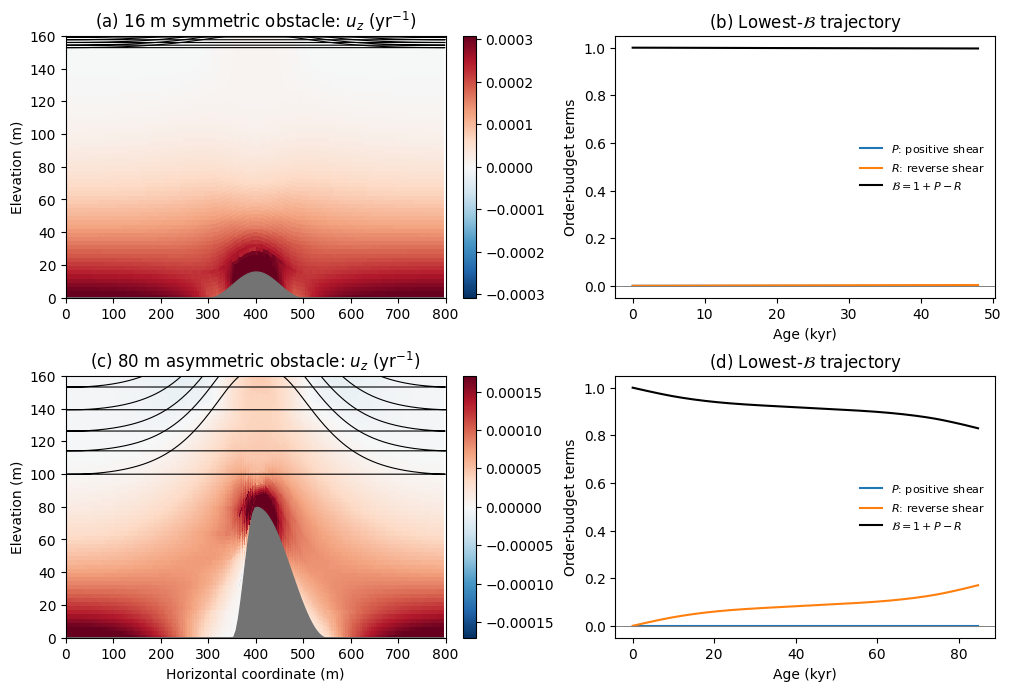

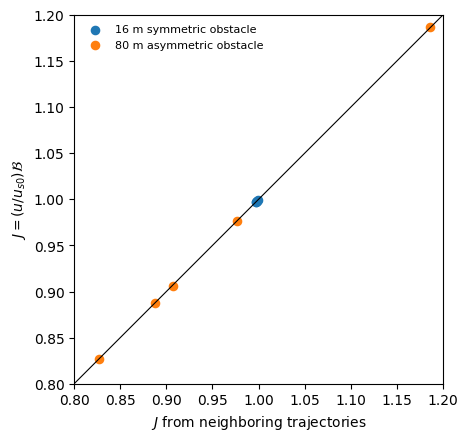

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

figure_directory = Path("figures")
figure_directory.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 6.8), constrained_layout=True)
for row, result in enumerate(results):
    ax = axes[row, 0]
    shear = result["fields"]["uz"]
    limit = np.nanpercentile(np.abs(shear), 98)
    image = ax.pcolormesh(
        result["X"], result["Z"], shear,
        cmap="RdBu_r", norm=TwoSlopeNorm(0, -limit, limit), shading="auto"
    )
    bed = bed_profile(result["x"], result["case"])
    ax.fill_between(result["x"], 0, bed, color="0.45")
    for trajectory in result["trajectories"]:
        ax.plot(
            np.mod(trajectory["budget"]["positions"][0], L),
            trajectory["budget"]["positions"][1],
            color="black", linewidth=0.8,
        )
    ax.set(xlim=(0, L), ylim=(0, H), ylabel="Elevation (m)")
    ax.set_title(f"({chr(97 + 2 * row)}) {result['case']['name']}: $u_z$ (yr$^{{-1}}$)")
    fig.colorbar(image, ax=ax, pad=0.01)

    ax = axes[row, 1]
    representative = min(result["trajectories"], key=lambda item: item["B"])
    age = representative["budget"]["times"] / 1000
    ax.plot(age, representative["budget"]["P"], label="$P$: positive shear")
    ax.plot(age, representative["budget"]["R"], label="$R$: reverse shear")
    ax.plot(age, representative["budget"]["B"], color="black", label="$\\mathcal{B}=1+P-R$")
    ax.axhline(0, color="0.5", linewidth=0.7)
    ax.set(xlabel="Age (kyr)", ylabel="Order-budget terms")
    ax.set_title(f"({chr(98 + 2 * row)}) Lowest-$\\mathcal{{B}}$ trajectory")
    ax.legend(frameon=False, fontsize=8)

axes[-1, 0].set_xlabel("Horizontal coordinate (m)")
fig.savefig(figure_directory / "full_stokes_order_budget.png", dpi=220)
plt.show()

fig, ax = plt.subplots(figsize=(5.2, 4.3), constrained_layout=True)
for case_name, group in summary.groupby("case"):
    ax.scatter(group["J_difference"], group["J_integral"], s=35, label=case_name)
extent = [0.80, 1.20]
ax.plot(extent, extent, color="black", linewidth=0.8)
ax.set(
    xlim=extent, ylim=extent, aspect="equal",
    xlabel="$J$ from neighboring trajectories",
    ylabel="$J=(u/u_{s0})\\mathcal{B}$",
)
ax.legend(frameon=False, fontsize=8)
fig.savefig(figure_directory / "order_identity_verification.png", dpi=220)
plt.show()

## Interpretation

The low obstacle weakly perturbs the trajectory order. The asymmetric obstacle produces a larger region with $u_z<0$, so that the reverse-shear expenditure $R$ is visible. Nevertheless, $\mathcal B$ remains positive for every sampled surface origin. Local reverse shear therefore does not produce overturning in these examples. Agreement between the integral and neighboring-trajectory estimates of $J$ checks both the budget calculation and the trajectory integration.

In [4]:
small = summary[summary["case"] == "16 m symmetric obstacle"]
large = summary[summary["case"] == "80 m asymmetric obstacle"]
print(f"Small obstacle: minimum B = {small.B.min():.4f}")
print(f"Asymmetric obstacle: minimum B = {large.B.min():.4f}")
print(f"Asymmetric obstacle: maximum R = {large.R.max():.4f}")
print(f"Maximum relative error in J = {summary.relative_J_error.max():.2e}")

Small obstacle: minimum B = 0.9966
Asymmetric obstacle: minimum B = 0.8295
Asymmetric obstacle: maximum R = 0.1705
Maximum relative error in J = 6.55e-04
